<a href="https://colab.research.google.com/github/FredyVG15/Entregas-/blob/main/Tutorial_PE.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# **TUTORIAL PARA TRABAJAR CON MATRICES EN SYMPY* Y DIBUJAR DIAGRAMAS DE TRANSICIÓN CON NETWORKX**
SymPy es una librería de Python para cálculo simbólico. A diferencia de NumPy (que es más numérico), SymPy permite trabajar con:

fracciones exactas, raíces, parámetros simbólicos,resultados exactos en eigenvalores/eigenvectores cuando se puede.



¿Cómo representar matrices en Sympy?
En primera instancia debemos importar la librería de la siguiente forma:

In [59]:
import sympy as sp

En SymPy, una matriz se crea con:

```python
 sp.Matrix([[...],[...],...])


La idea es que:


*   Cada lista interna representa un renglón (fila).
*   El número de elementos en cada renglón define el número de columnas.
*   SymPy detecta automáticamente el tamaño (m x n).

Veamos un ejemplo:

In [60]:
A = sp.Matrix([[1, 2, 3],[0, 1, 4],[2, 0, 1]])

B = sp.Matrix([[1, 0, 2],[3, 1, 0],[1, 2, 1]])

A

Matrix([
[1, 2, 3],
[0, 1, 4],
[2, 0, 1]])

In [61]:
B

Matrix([
[1, 0, 2],
[3, 1, 0],
[1, 2, 1]])

Adicionalmente, podemos ver u obtener las dimensiones para cada matriz a analizar.Es decir, cuantas filas y columnas conforman una matriz (filas, columnas). Pare ello, se utiliza lo siguiente:

In [62]:
A.shape, B.shape

((3, 3), (3, 3))

Otra cosa que se puede obtener es Obtener entradas: renglón, columna o alguna entrada específica.
SymPy indexa igual que Python: empieza en 0.



*   $A[i, j]$  devuelve el elemento de la fila $i$ y columna $j$.
*  $ A.row(i) $ devuelve la fila $i$ como matriz $1 × n.$
*  $ A.col(j)$ devuelve la columna $j$ como matriz $m × 1.$


Esto es clave porque en álgebra lineal, acceder a elementos permite construir submatrices, verificar entradas, crear sistemas lineales, etc.

Entrada específica A[i,j]

In [63]:
# Entrada en fila 0, columna 2
A[0, 2]

3

Obtener un renglón completo

In [64]:
# Fila 1 (segundo renglón) completa
A.row(1)

Matrix([[0, 1, 4]])

Obtener una columna completa

In [65]:
# Columna 2 (tercera columna) completa
A.col(2)

Matrix([
[3],
[4],
[1]])

Submatrices (slicing)

In [66]:
# Submatriz: filas 0 y 1; columnas 0 y 1
A[0:2, 0:2]

Matrix([
[1, 2],
[0, 1]])


## **Producto de matrices**

Supongamos que tenemos dos matrices:

- $A$ de tamaño $m \times n$
- $B$ de tamaño $n \times p$

Para que el producto de matrices esté definido, **el número de columnas de $A$ debe ser igual al número de renglones de $B$**.

$$
A_{m \times n} \quad \text{y} \quad B_{n \times p}
$$

Entonces, el producto:

$$
AB
$$

**existe** y la matriz resultante tendrá tamaño:

$$
AB \in \mathbb{R}^{m \times p}
$$

---

### **Cálculo de cada entrada del producto**

Cada elemento de la matriz producto se obtiene multiplicando los elementos correspondientes del renglón $i$ de $A$ con la columna $j$ de $B$ y sumándolos.

La fórmula general es:

$$
(AB)_{ij} = \sum_{k=1}^{n} A_{ik} B_{kj}
$$

donde:

- $i$ indica el **renglón**
- $j$ indica la **columna**
- $k$ recorre los elementos que se multiplican y suman
-
En SymPy, el producto matricial se hace con *:

A * B es producto matricial.

In [67]:
AB = A * B #Obtenemos el poroducto matricial En SymPy, el producto matricial se hace con *
AB

Matrix([
[10, 8, 5],
[ 7, 9, 4],
[ 3, 2, 5]])

In [68]:
A.shape, B.shape, AB.shape #Para verificación de tamaños

((3, 3), (3, 3), (3, 3))

## **Potencia de una matriz**

Elevar una matriz a una potencia significa **multiplicarla por sí misma varias veces**.

Por ejemplo:

$$
A^2 = A \cdot A
$$

$$
A^3 = A \cdot A \cdot A
$$

En general, para una potencia entera positiva $n$:

$$
A^n = \underbrace{A \cdot A \cdot A \cdots A}_{n \text{ veces}}
$$

---

### Aplicaciones

La potencia de matrices aparece frecuentemente en:

- **Cadenas de Markov**, utilizando la matriz de transición elevada a una potencia:

$$
P^n
$$

- **Dinámica de sistemas lineales**.

- **Conteo de caminos en grafos**, donde $A^n$ indica el número de caminos de longitud $n$ entre nodos.

---

### Uso en SymPy

En **SymPy**, elevar una matriz a una potencia entera $n$ es muy sencillo:

```python
A**n

In [69]:
#Por ejemplo: A^2 y A^5
A2 = A**2
A5 = A**5
A2

Matrix([
[7, 4, 14],
[8, 1,  8],
[4, 4,  7]])

In [70]:
A5

Matrix([
[593, 362, 991],
[448, 257, 724],
[362, 224, 593]])

## **Multiplicar vectores por matrices**

### Explicación

Un **vector en SymPy** también se representa como una **Matrix**.

---

### Vector columna $(n \times 1)$

Un vector columna tiene la forma:

$$
v =
\begin{pmatrix}
v_1 \\
v_2 \\
\vdots \\
v_n
\end{pmatrix}
$$

Se crea en **SymPy** con:

```python
sp.Matrix([v1, v2, ..., vn])


Vector fila (1 × n)

$$
u = (u_1, u_2, \ldots, u_n)
$$

Se crea con:

`sp.Matrix([[u1, u2, ..., un]])`

Multiplicación típica:

- Matriz por vector columna:

$$
Av
$$

- Vector fila por matriz:

$$
uA
$$


In [71]:
#PARA MATRIZ POR VECTOR COLUMNA
v = sp.Matrix([1, 2, -1])  # 3x1
Av = A * v
Av

Matrix([
[ 2],
[-2],
[ 1]])

In [72]:
#PARA VECTOR FILA POR MATRIZ
u = sp.Matrix([[1, 0, 2]])  # 1x3
uA = u * A
uA

Matrix([[5, 2, 5]])

###  **Valores propios y vectores propios (eigenvaloress/eigenvectores)**


Los **valores propios** (eigenvalores) de una matriz $A$ son los números $\lambda$ que satisfacen:

$$
Av = \lambda v
$$

donde $v \neq 0$ es un vector propio (eigenvector).

Interpretación:

- $A$ transforma el vector $v$, pero solo lo estira o encoge, sin cambiar su dirección (solo escala).

Para hallar $\lambda$, se resuelve:

$$
\det(A - \lambda I) = 0
$$

En SymPy:

`A.eigenvals()` devuelve un diccionario `{eigenvalor: multiplicidad}`.

 `A.eigenvects()` devuelve una lista con tuplas:

 `(eigenvalor, multiplicidad, [base_de_vectores_propios])`


### **Calcular los valores propios**

Los **valores propios** se obtienen resolviendo:

$$
\det(A - \lambda I) = 0
$$

donde:

- $I$ es la **matriz identidad**
- $\lambda$ es el **valor propio**

SymPy puede calcularlos automáticamente.
```python
A.eigenvals()

La función anterior regresa devuelve un diccionario con:
```python
{valor_propio : multiplicidad}

In [73]:
eig_vals = A.eigenvals()
eig_vals

{2/(2*sqrt(14) + 8)**(1/3) + 1 + (2*sqrt(14) + 8)**(1/3): 1,
 1 + 2/((-1/2 + sqrt(3)*I/2)*(2*sqrt(14) + 8)**(1/3)) + (-1/2 + sqrt(3)*I/2)*(2*sqrt(14) + 8)**(1/3): 1,
 1 + (-1/2 - sqrt(3)*I/2)*(2*sqrt(14) + 8)**(1/3) + 2/((-1/2 - sqrt(3)*I/2)*(2*sqrt(14) + 8)**(1/3)): 1}


### **Calcular los vectores propios**

Los **vectores propios** son los vectores $v$ que cumplen:

$$
Av = \lambda v
$$

SymPy permite calcularlos con:
```python
eigenvects()

In [74]:
eig_vecs = A.eigenvects()
eig_vecs

[(1 + (-1/2 - sqrt(3)*I/2)*(2*sqrt(14) + 8)**(1/3) + 2/((-1/2 - sqrt(3)*I/2)*(2*sqrt(14) + 8)**(1/3)),
  1,
  [Matrix([
   [                                                                                                                    (-1/2 - sqrt(3)*I/2)*(2*sqrt(14) + 8)**(1/3)/2 + 1/((-1/2 - sqrt(3)*I/2)*(2*sqrt(14) + 8)**(1/3))],
   [-7/4 - 1/((-1/2 - sqrt(3)*I/2)*(2*sqrt(14) + 8)**(1/3)) + (1 + (-1/2 - sqrt(3)*I/2)*(2*sqrt(14) + 8)**(1/3) + 2/((-1/2 - sqrt(3)*I/2)*(2*sqrt(14) + 8)**(1/3)))**2/4 - (-1/2 - sqrt(3)*I/2)*(2*sqrt(14) + 8)**(1/3)/2],
   [                                                                                                                                                                                                                    1]])]),
 (1 + 2/((-1/2 + sqrt(3)*I/2)*(2*sqrt(14) + 8)**(1/3)) + (-1/2 + sqrt(3)*I/2)*(2*sqrt(14) + 8)**(1/3),
  1,
  [Matrix([
   [                                                                                            

Asimismo, podemos imprimir eigenpares de forma un poco más clara, de la siguiente forma:

In [75]:
for lam, mult, vects in A.eigenvects():
    print("λ =", lam, "| multiplicidad =", mult)
    print("Base de eigenvectores:")
    for vec in vects:
        sp.pprint(vec)
    print("-"*40)

λ = 1 + (-1/2 - sqrt(3)*I/2)*(2*sqrt(14) + 8)**(1/3) + 2/((-1/2 - sqrt(3)*I/2)*(2*sqrt(14) + 8)**(1/3)) | multiplicidad = 1
Base de eigenvectores:
⎡                                   ⎛  1   √3⋅ⅈ⎞ 3 ___________                 ↪
⎢                                   ⎜- ─ - ────⎟⋅╲╱ 2⋅√14 + 8                  ↪
⎢                                   ⎝  2    2  ⎠                             1 ↪
⎢                                   ────────────────────────── + ───────────── ↪
⎢                                               2                ⎛  1   √3⋅ⅈ⎞  ↪
⎢                                                                ⎜- ─ - ────⎟⋅ ↪
⎢                                                                ⎝  2    2  ⎠  ↪
⎢                                                                              ↪
⎢                                                                              ↪
⎢                                   ⎛    ⎛  1   √3⋅ⅈ⎞ 3 ___________            ↪
⎢                                   ⎜1 + ⎜-

## **Para dibujar un diagrama de transición con NetworkX**

En este tutorial aprenderemos cómo construir un diagrama de transición usando la librería **NetworkX** en Python.

Un diagrama de transición representa:

- Estados → nodos del grafo  
- Transiciones entre estados → flechas  
- Probabilidades de transición → etiquetas en las flechas  

Este tipo de diagramas se utiliza en:

- Cadenas de Markov  
- Procesos estocásticos  
- Modelos probabilísticos  




## Consideremos el siguiente ejemplo:

Supongamos que se tiene un sistema con solo dos **estados**:

- **0 →** La máquina funciona  
- **1 →** La máquina está descompuesta  

Las probabilidades de transición son:

| Estado actual | Estado siguiente | Probabilidad |
|---------------|------------------|--------------|
| 0 | 0 | 0.9 |
| 0 | 1 | 0.1 |
| 1 | 0 | 0.6 |
| 1 | 1 | 0.4 |

Esto significa que:

- Si la máquina **funciona hoy**, mañana:
  - seguirá funcionando con probabilidad **0.9**
  - fallará con probabilidad **0.1**

- Si la máquina **está descompuesta**, mañana:
  - será reparada con probabilidad **0.6**
  - seguirá fallando con probabilidad **0.4**



### Matriz de transición

Estas probabilidades pueden representarse mediante la **matriz de transición**:

$$
P =
\begin{pmatrix}
0.9 & 0.1 \\
0.6 & 0.4
\end{pmatrix}
$$

donde la fila representa el **estado actual** y la columna el **estado siguiente**.

Nuestro objetivo será **dibujar el diagrama de transición de este sistema**.

## Importar librerías

Para construir y visualizar el diagrama de transición utilizaremos dos librerías de Python:

### 1. NetworkX
Permite **construir grafos**, es decir, estructuras formadas por:

- **Nodos** → representan los estados  
- **Aristas (edges)** → representan las transiciones entre estados  

### 2. Matplotlib
Permite **visualizar el grafo**, es decir, dibujar el diagrama de transición de manera gráfica.

In [76]:
import networkx as nx
import matplotlib.pyplot as plt

### **Paso 1: Crear el grafo dirigido**

Un diagrama de transición es un **grafo dirigido**, porque las transiciones tienen dirección.

Por ejemplo:

0 → 1  

no es lo mismo que  

1 → 0

En NetworkX los grafos dirigidos se crean con:

`nx.DiGraph()`

In [77]:
G = nx.DiGraph()

### **Paso 2: Agregar los estados (nodos)**

Los **estados del sistema** se representan como nodos del grafo.

En nuestro ejemplo los estados son:

- **0 →** funcionando  
- **1 →** descompuesta

In [78]:
G.add_nodes_from([0,1])

### **Paso 3: Agregar las transiciones**

Las **transiciones** se representan con aristas dirigidas.

Cada transición tiene una probabilidad, que podemos guardar como un atributo llamado `weight`.

La sintaxis general es:
```python
G.add_edge(estado_origen, estado_destino, weight = probabilidad)

En nuestro ejemplo las probabilidades de transición son:

- *0 → 0* con probabilidad *0.9*
- *0 → 1* con probabilidad *0.1*
- *1 → 0* con probabilidad *0.6*
- *1 → 1* con probabilidad *0.4*

En NetworkX las transiciones se agregan como *aristas dirigidas* del grafo.
Después de este paso normalmente viene la celda de código en Python, por ejemplo:

In [79]:
G.add_edge(0,0, weight=0.9)
G.add_edge(0,1, weight=0.1)
G.add_edge(1,0, weight=0.6)
G.add_edge(1,1, weight=0.4)

### **Paso 4: Definir posiciones para los nodos**

Para dibujar el grafo necesitamos definir la posición de los nodos.

NetworkX tiene varios algoritmos automáticos.

Uno muy común es:
```python
spring_layout()


In [80]:
pos = nx.spring_layout(G)

### **Paso 5: Para dibujar el diagrama de transición**

Entonces, así podemos visualizar el grafo.

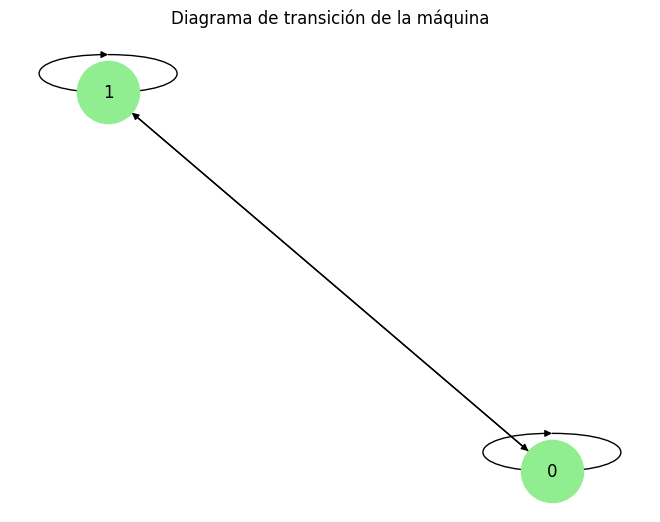

In [81]:
nx.draw(G,
        pos,
        with_labels=True,
        node_color="lightgreen",
        node_size=2000,
        arrows=True)

plt.title("Diagrama de transición de la máquina")
plt.show()

### **Paso 6: Para mostrar las probabilidades en las transiciones**

Las probabilidades se guardaron como atributos de las aristas.

Asi, ahora se pueden mostrarlas en el diagrama.

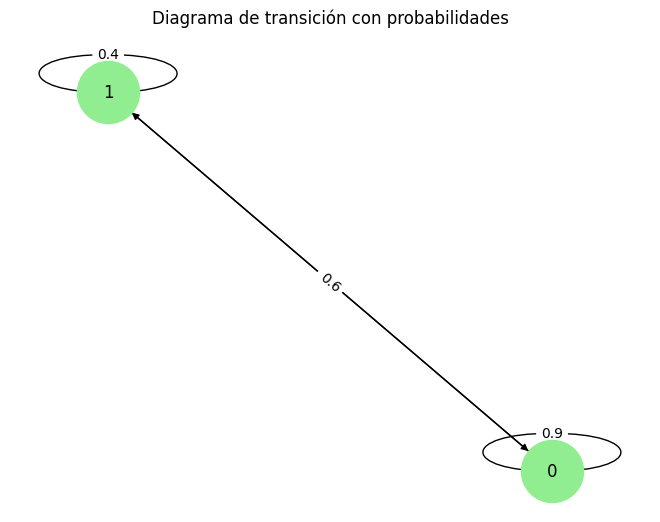

In [82]:
labels = nx.get_edge_attributes(G,"weight")

nx.draw(G,
        pos,
        with_labels=True,
        node_color="lightgreen",
        node_size=2000,
        arrows=True)

nx.draw_networkx_edge_labels(G,pos,edge_labels=labels)

plt.title("Diagrama de transición con probabilidades")
plt.show()

### **Interpretación del diagrama**

En el diagrama se puede apreciar:

- El nodo **0** representa el estado **máquina funcionando**.
- El nodo **1** representa el estado **máquina descompuesta**.

Las flechas indican las **transiciones posibles** entre estados.

Por ejemplo:

- **0 → 1** con probabilidad **0.1** significa que la máquina puede fallar.
- **1 → 0** con probabilidad **0.6** significa que la máquina puede ser reparada.

Este tipo de diagramas permite visualizar fácilmente el **comportamiento probabilístico de un sistema**.

 Con este procedimiento podemos construir **diagramas de transición simples usando NetworkX en Python**.